In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
df = pd.read_csv("preprocessed_data_1.csv")
median_salary = df["Salary_LPA"].median()

df["Salary_Class"] = (
    df["Salary_LPA"] >= median_salary
).astype(int)
X = df[
    [
        "Age",
        "Experience_Years",
        "Education",
        "Department",
        "Job_Level",
        "Performance_Rating",
        "Projects_Completed",
        "Certifications",
        "Weekly_Work_Hours",
        "Remote_Work",
        "City_Tier",
        "Job_Satisfaction"
    ]
]
X = pd.get_dummies(
    X,
    drop_first=True
)

y = df["Salary_Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = KNeighborsClassifier(
    n_neighbors=7
)
model.fit(X_train, y_train)
print("\nKNN Model Trained Successfully!")

y_pred = model.predict(X_test)

print("\nKNN Model")
print("-------------------")
print("Median Salary:", median_salary)


result = pd.DataFrame({
    "Actual Salary Class": y_test.values,
    "Predicted Salary Class": y_pred
})

print("\nActual vs Predicted Salary Class")
print(result.head(10))


KNN Model Trained Successfully!

KNN Model
-------------------
Median Salary: 2.1

Actual vs Predicted Salary Class
   Actual Salary Class  Predicted Salary Class
0                    1                       1
1                    0                       0
2                    0                       0
3                    1                       1
4                    0                       0
5                    1                       1
6                    1                       1
7                    0                       0
8                    1                       1
9                    0                       0


In [49]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , f1_score , recall_score , precision_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

confusion_matrix = confusion_matrix(y_test,y_pred)
print("Confusion matrix: ",confusion_matrix)

classification_report = classification_report(y_test,y_pred)
print("Classification_report: ",classification_report)

f1_score = f1_score(y_test,y_pred)
print("f1_score: ",f1_score)

recall_score = recall_score(y_test,y_pred)
print("recall_score:",recall_score)

precision_score = precision_score(y_test,y_pred)
print("precision_score: ",precision_score)


Accuracy: 0.948
Confusion matrix:  [[235  15]
 [ 11 239]]
Classification_report:                precision    recall  f1-score   support

           0       0.96      0.94      0.95       250
           1       0.94      0.96      0.95       250

    accuracy                           0.95       500
   macro avg       0.95      0.95      0.95       500
weighted avg       0.95      0.95      0.95       500

f1_score:  0.9484126984126984
recall_score: 0.956
precision_score:  0.9409448818897638


In [50]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



mean_absolute_error = mean_absolute_error(y_test, y_pred)

mean_squared_error = mean_squared_error(y_test, y_pred)

rmse = mean_squared_error ** 0.5

r2 = r2_score(y_test, y_pred)
print("MAE :", mean_absolute_error)
print("MSE :", mean_squared_error)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.052
MSE : 0.052
RMSE: 0.22803508501982758
R2 Score: 0.792


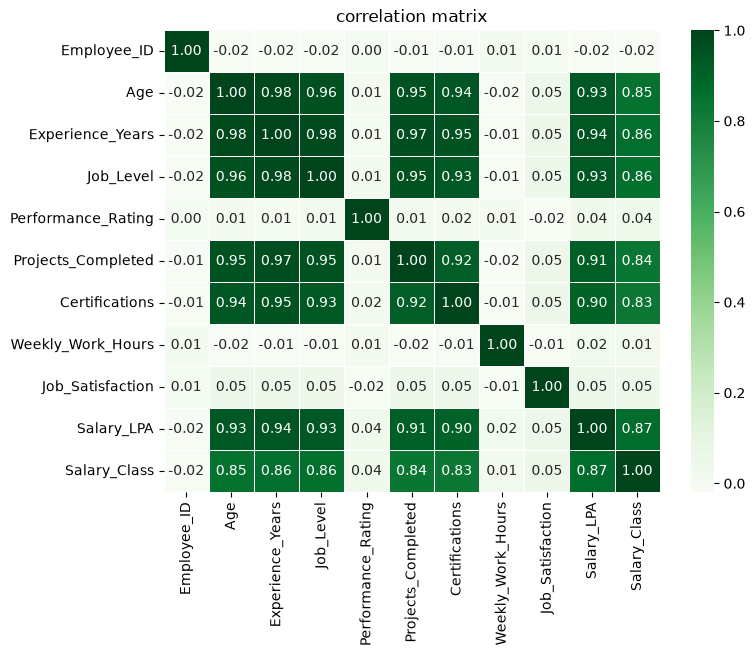

In [51]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5
)
plt.title("correlation matrix")
plt.show()
